# Matchup Heatmap

Run co-evolution on the synthetic card pool, then visualize the matchup matrix as a heatmap.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from analysis.visualize import matchup_heatmap_data
from deckbuilding.deck import CARD_POOL
from deckbuilding.coevolution import CoevolutionConfig, CoevolutionEngine

In [3]:
config = CoevolutionConfig(
    pool=CARD_POOL,
    population_size=20,
    generations=5,
    opponents_per_eval=5,
    games_per_matchup=3,
    seed=42,
    max_turns_per_game=30,
)

engine = CoevolutionEngine(config)
results = engine.run()

best, score = results[0]
print(f'Best deck fitness: {score:.3f}')
print(f'Best deck: {best}')
print()
for entry in engine.meta_tracker.get_meta_summary():
    print(f"  {entry['name']}: {entry['win_rate']:.1%} win rate, {entry['popularity']:.1%} popularity")

Best deck fitness: 0.733
Best deck: ['Adept', 'Brute', 'Adept', 'Shield', 'Poison', 'Giant', 'Brute', 'Healer', 'Tiny', 'Brute', 'Tiny', 'Healer', 'Poison', 'Giant', 'Wasp', 'Brute', 'Healer', 'Brute', 'Shield', 'Poison', 'Shield', 'Adept', 'Giant', 'Adept', 'Brute', 'Giant', 'Poison', 'Poison', 'Healer', 'Brute']

  Midrange: 59.4% win rate, 80.2% popularity
  Aggro: 39.0% win rate, 72.5% popularity


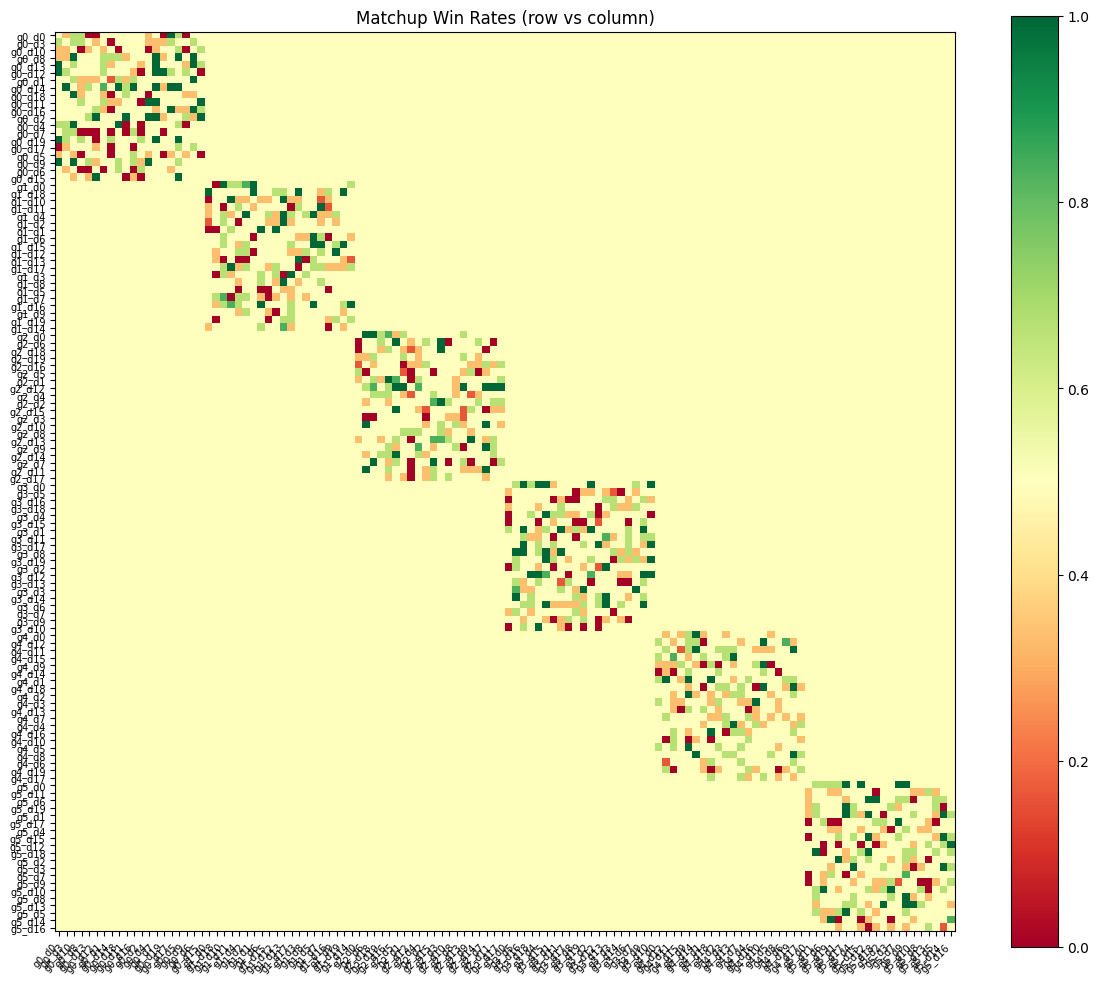

In [4]:
heatmap = matchup_heatmap_data(engine.matchup_matrix)
labels = heatmap['labels']
grid = np.array([[v if v is not None else 0.5 for v in row]
                 for row in heatmap['values']])

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(labels)), labels, fontsize=7)
ax.set_title('Matchup Win Rates (row vs column)')
plt.colorbar(im)
plt.tight_layout()
plt.show()